<a href="https://colab.research.google.com/github/akhilesh-uib/GEO4171/blob/main/flood_frequency_analysis_nve_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> GEO4171 </center>
#  <center> Exploring NVE's Discharge dat and Regional Flood Frequency Analysis </center>
***

This notebook performs hydrological extreme value analysis including:
- Time series visualization
- Annual maximum extraction
- Seasonal pattern analysis
- Flood rose plot
- GEV distribution fitting (L-moments)
- Return level estimation
- Diagnostic plots
***

In [1]:
! pip install lmoments3
! pip install pymannkendall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genextreme
import lmoments3 as lm
import lmoments3.distr as lm_distr
import pymc as pm
import arviz as az
plt.style.use('seaborn-v0_8-colorblind')

In [4]:
from google.colab import files
uploaded = files.upload()

Saving 62.5.0-Vannføring-dogn-v1.csv to 62.5.0-Vannføring-dogn-v1.csv


In [6]:
uploaded.keys()

dict_keys(['62.5.0-Vannføring-dogn-v1.csv'])

In [7]:
file_path = '/content/62.5.0-Vannføring-dogn-v1.csv'

df = pd.read_csv(file_path, sep=';', skiprows=1)
df.columns = ['time', 'discharge', 'corrected', 'quality']
df['time'] = pd.to_datetime(df['time'], utc=True)
df['discharge'] = (
    df['discharge']
    .str.replace(',', '.', regex=False)
    .astype(float)
)
df['discharge'] = pd.to_numeric(df['discharge'])
df = df.dropna(subset=['discharge'])
df = df.set_index('time')

df.head()


,discharge,corrected,quality
time,,,
1892-01-01 11:00:00+00:00,12.10079,0,3
1892-01-02 11:00:00+00:00,11.24779,0,3
1892-01-03 11:00:00+00:00,11.24779,0,3
1892-01-04 11:00:00+00:00,10.97214,0,3
1892-01-05 11:00:00+00:00,11.24779,0,3


## Time Series and Annual Maxima

In [8]:
annual_max = df['discharge'].resample('YE').max()
annual_max.head()

,discharge
time,
1892-12-31 00:00:00+00:00,356.5735
1893-12-31 00:00:00+00:00,304.5116
1894-12-31 00:00:00+00:00,258.9497
1895-12-31 00:00:00+00:00,228.6367
1896-12-31 00:00:00+00:00,339.8720


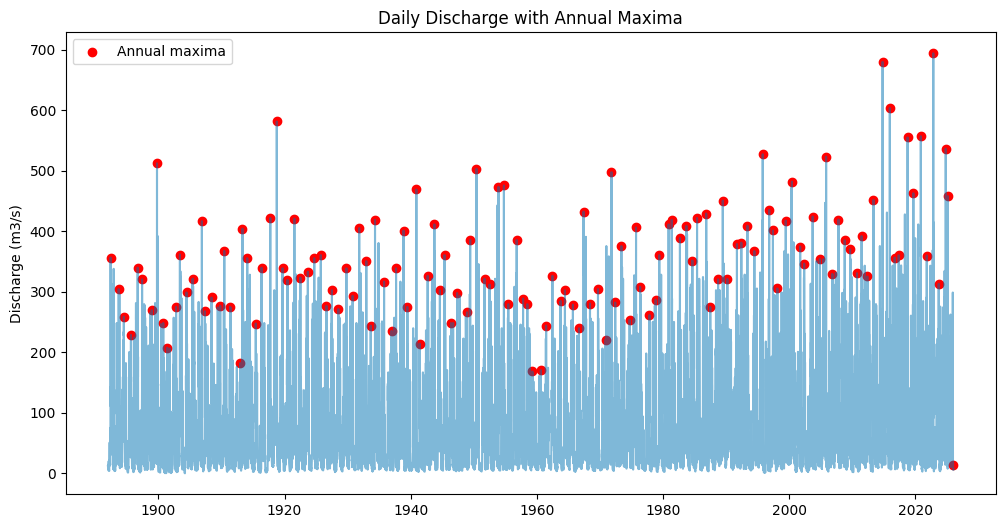

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['discharge'], alpha=0.5)
plt.scatter(df['discharge'].groupby(df.index.year).idxmax().values, annual_max.values,
            color='red', marker='o', label='Annual maxima')

plt.title('Daily Discharge with Annual Maxima')
plt.ylabel('Discharge (m3/s)')
plt.legend()
plt.show()

## Seasonality Analysis

In [10]:
monthly_mean = df['discharge'].groupby(df.index.month).mean()
monthly_mean.head()

,discharge
time,
1,24.379268
2,20.331614
3,20.361550
4,39.436203
5,124.376439


In [11]:
# Determine the midpoint of the DataFrame
midpoint = len(df) // 2

# Split the DataFrame into first half and second half
first_half = df.iloc[:midpoint]
second_half = df.iloc[midpoint:]

# Compute monthly mean for each half
monthly_mean_first = first_half['discharge'].groupby(first_half.index.month).mean()
monthly_mean_second = second_half['discharge'].groupby(second_half.index.month).mean()

# Show the first few values for each
print("First half monthly mean:")
print(monthly_mean_first.head())

print("\nSecond half monthly mean:")
print(monthly_mean_second.head())

First half monthly mean:
time
1     21.264915
2     18.738485
3     17.450715
4     34.560401
5    116.843999
Name: discharge, dtype: float64

Second half monthly mean:
time
1     27.493621
2     21.923901
3     23.272385
4     44.312005
5    131.908879
Name: discharge, dtype: float64


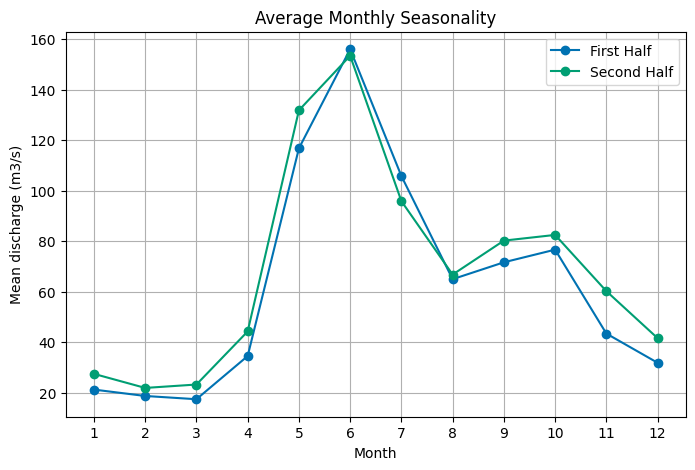

In [12]:
plt.figure(figsize=(8,5))
plt.plot(monthly_mean_first.index, monthly_mean_first.values, marker='o', label='First Half')
plt.plot(monthly_mean_second.index, monthly_mean_second.values, marker='o', label='Second Half')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Mean discharge (m3/s)')
plt.title('Average Monthly Seasonality')
plt.legend()
plt.grid()
plt.show()

## Flood Rose

In [13]:
df.head()
df['year'] = df.index.year
annual_max = df.groupby('year')['discharge'].idxmax()
max_values = df.loc[annual_max]
max_values.index.dayofyear

Index([155, 259, 190, 237, 263, 152, 347, 286, 283, 155,
       ...
       139, 288, 258, 324, 302, 316, 264, 306,  65,   1],
      dtype='int32', name='time', length=135)

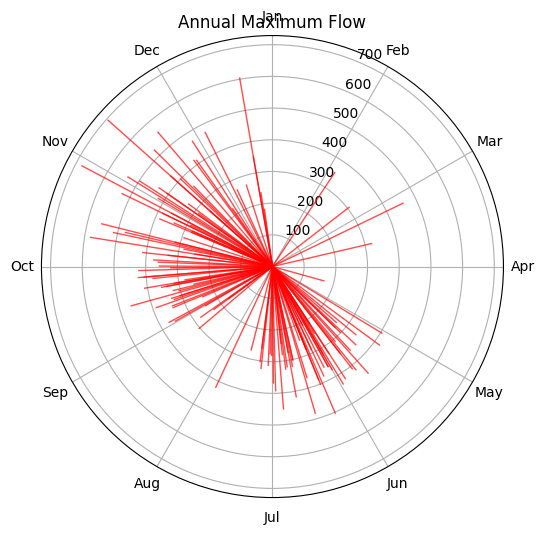

In [14]:
def flood_rose(df, qth=0.95):
    df = df.copy().sort_index()
    discharge = df['discharge']

    # --- Polar plot: annual maximum floods ---
    # Group by year and find the day of maximum discharge
    df['year'] = df.index.year
    annual_max = df.groupby('year')['discharge'].idxmax()  # index of max in each year
    max_values = df.loc[annual_max]


    theta = 2 * np.pi * (max_values.index.dayofyear / 365)
    r = max_values['discharge'].values

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    for t, radius in zip(theta, r):
        ax.plot([t, t], [0, radius], linewidth=1, color='red', alpha=0.7)

    # Month labels
    month_angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    ax.set_xticks(month_angles)
    ax.set_xticklabels(month_labels)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Annual Maximum Flow')

    plt.show()

flood_rose(df)

## Trend analysis

Mann-Kendall Trend Test for Annual Maximum Floods
Trend: increasing
Hypothesis: True (0=No trend, 1=Trend exists)
p-value: 5.028446581567536e-06
Slope: 0.8903769230769242
Intercept: 280.2167461538461


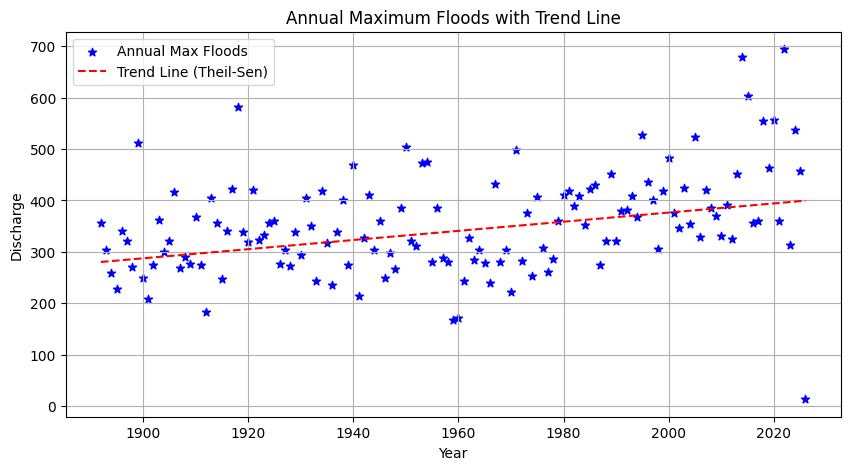

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

def ams_trend_test_with_plot(df):
    df = df.copy().sort_index()

    # Extract annual maximum discharge
    df['year'] = df.index.year
    annual_max = df.groupby('year')['discharge'].max()

    # Mann-Kendall test
    result = mk.original_test(annual_max)

    # Print summary
    print("Mann-Kendall Trend Test for Annual Maximum Floods")
    print(f"Trend: {result.trend}")
    print(f"Hypothesis: {result.h} (0=No trend, 1=Trend exists)")
    print(f"p-value: {result.p}")
    print(f"Slope: {result.slope}")
    print(f"Intercept: {result.intercept}")

    # --- Plot ---
    plt.figure(figsize=(10,5))
    plt.scatter(annual_max.index, annual_max.values, marker='*', linestyle='-', label='Annual Max Floods', color='blue')

    # Trend line: Theil-Sen slope
    trend_line = result.intercept + result.slope * (annual_max.index - annual_max.index.min())
    plt.plot(annual_max.index, trend_line, color='red', linestyle='--', label='Trend Line (Theil-Sen)')

    plt.xlabel('Year')
    plt.ylabel('Discharge (m3/s)')
    plt.title('Annual Maximum Floods with Trend Line')
    plt.grid(True)
    plt.legend()
    plt.show()

    return result

trend_result = ams_trend_test_with_plot(df)

## Fit GEV Distribution (L-moments)

In [ ]:
annual_max = df['discharge'].resample('YE').max()
data = annual_max.values
annual_max.head()

time
1892-12-31 00:00:00+00:00    356.5735
1893-12-31 00:00:00+00:00    304.5116
1894-12-31 00:00:00+00:00    258.9497
1895-12-31 00:00:00+00:00    228.6367
1896-12-31 00:00:00+00:00    339.8720
Freq: YE-DEC, Name: discharge, dtype: float64

In [ ]:
# Fit GEV directly (internally uses L-moments)
gev_params = lm_distr.gev.lmom_fit(annual_max.values)

print("GEV Parameters:")
print(gev_params)

GEV Parameters:
OrderedDict([('c', np.float64(0.09625909966749782)), ('loc', np.float64(312.87768989299184)), ('scale', np.float64(84.48976890479618))])


## Return Periods

In [ ]:
return_periods = np.array([100, 200, 1000])
probabilities = 1 - 1 / return_periods

return_levels = distr.gev.ppf(probabilities, **gev_params)

for T, rl in zip(return_periods, return_levels):
    print(f"{T}-year return level: {rl:.2f}")

100-year return level: 626.90
200-year return level: 663.41
1000-year return level: 739.16


## Diagnostic Plots

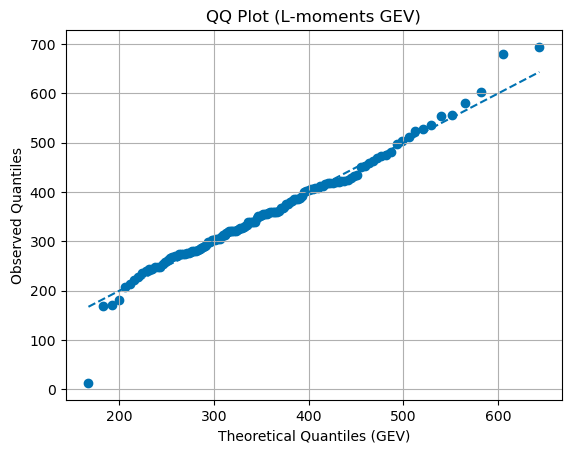

In [ ]:
# Fit distribution
fit_gev = lm_distr.gev.lmom_fit(data)
obs = np.sort(data)
n = len(obs)

# Weibull plotting position
p = np.arange(1, n + 1) / (n + 1)

# Theoretical quantiles using lm_distr
theo = lm_distr.gev.ppf(p, **fit_gev)

plt.figure()
plt.scatter(theo, obs)
plt.plot(theo, theo, linestyle='--')
plt.xlabel("Theoretical Quantiles (GEV) (m3/s)")
plt.ylabel("Observed Quantiles (m3/s)")
plt.title("QQ Plot (L-moments GEV)")
plt.grid()
plt.show()

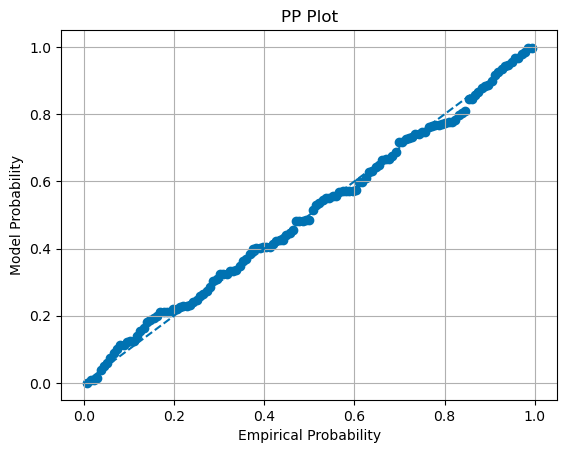

In [ ]:
# Empirical probabilities
emp_p = np.arange(1, n + 1) / (n + 1)

# Model probabilities
model_p = lm_distr.gev.cdf(obs, **fit_gev)

plt.figure()
plt.scatter(emp_p, model_p)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Empirical Probability")
plt.ylabel("Model Probability")
plt.title("PP Plot")
plt.grid()
plt.show()

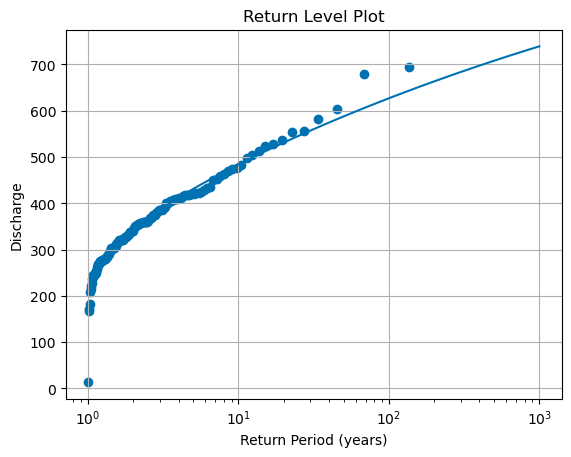

In [ ]:
# Return periods
T = np.logspace(0.5, 3, 100)
p = 1 - 1 / T

# Model return levels
rl_model = lm_distr.gev.ppf(p, **fit_gev)

# Empirical return periods
rank = np.arange(1, n + 1)[::-1]
T_emp = (n + 1) / rank

plt.figure()
plt.scatter(T_emp, obs)
plt.plot(T, rl_model)
plt.xscale('log')
plt.xlabel("Return Period (years)")
plt.ylabel("Discharge (m3/s)")
plt.title("Return Level Plot")
plt.grid()
plt.show()

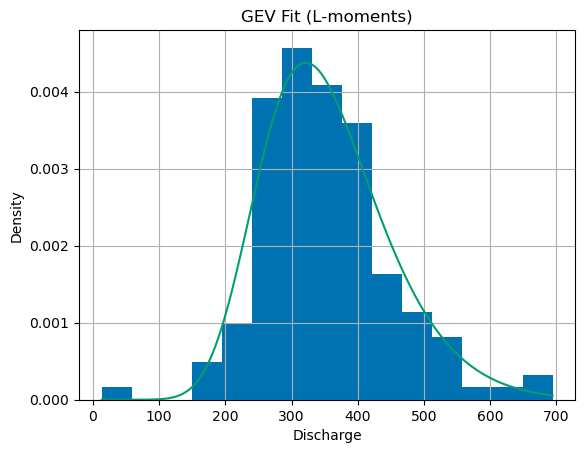

In [ ]:
x = np.linspace(min(data), max(data), 200)

pdf = lm_distr.gev.pdf(x, **fit_gev)

plt.figure()
plt.hist(data, bins=15, density=True)
plt.plot(x, pdf)
plt.xlabel("Discharge (m3/s)")
plt.ylabel("Density (m3/s)")
plt.title("GEV Fit (L-moments)")
plt.grid()
plt.show()

## Confidence intervals on the fitted GEV using Bootstrapping

GEV Parameters:
OrderedDict([('c', np.float64(0.09625909966749782)), ('loc', np.float64(312.87768989299184)), ('scale', np.float64(84.48976890479618))])
GEV Parameters:
OrderedDict([('c', np.float64(0.09625909966749782)), ('loc', np.float64(312.87768989299184)), ('scale', np.float64(84.48976890479618))])


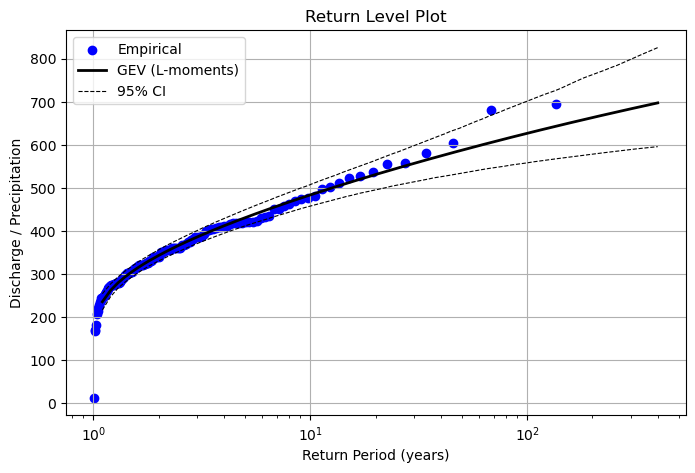

100-year return level: 626.90
200-year return level: 663.41
1000-year return level: 739.16


In [ ]:
# Fit GEV using L-moments
gev_params = lm_distr.gev.lmom_fit(annual_max.values)
print("GEV Parameters:")
print(gev_params)

obs = np.sort(annual_max.values)  # ascending
n = len(obs)

# Empirical return periods (largest obs gets largest T)
rank = np.arange(1, n + 1)[::-1]
T_emp = (n + 1) / rank

# Fit GEV using your lm_distr object
gev_params = lm_distr.gev.lmom_fit(annual_max.values)
print("GEV Parameters:")
print(gev_params)

# Return periods for plotting
T_model = np.linspace(1.1, 400, 4000)
prob_model = 1 - 1 / T_model
rl_model = lm_distr.gev.ppf(prob_model, **gev_params)

# Bootstrap resampling for 95% CI
n_boot = 1000
returns_boot = np.zeros((len(T_model), n_boot))
for i in range(n_boot):
    sample = annual_max.sample(n=n, replace=True).values
    params_boot = lm_distr.gev.lmom_fit(sample)
    returns_boot[:, i] = lm_distr.gev.ppf(1 - 1 / T_model, **params_boot)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(T_emp, obs, label='Empirical', color='blue')
plt.plot(T_model, rl_model, c='k', lw=2, label='GEV (L-moments)')
plt.plot(T_model, np.quantile(returns_boot, 0.05, axis=1), 'k--', lw=0.8, label='95% CI')
plt.plot(T_model, np.quantile(returns_boot, 0.95, axis=1), 'k--', lw=0.8)
plt.xscale('log')
plt.xlabel("Return Period (years)")
plt.ylabel("Discharge (m3/s)")
plt.title("Return Level Plot")
plt.grid(True)
plt.legend()
plt.show()


return_periods = np.array([100, 200, 1000])
probabilities = 1 - 1 / return_periods
return_levels = lm_distr.gev.ppf(probabilities, **gev_params)
for T, rl in zip(return_periods, return_levels):
    print(f"{T}-year return level: {rl:.2f}")